# Location-Omission Ablation Study
## How Does Spatial Sparsification Degrade WiFi Fingerprint Localization?

**Goal:** Systematically remove 10 %, 20 %, … 70 % of reference locations from the
training set and measure the impact on every model (kNN, SVR, XGBoost, DNN) across
both feature tracks (Full vs. Selected).

**Omission strategy — Farthest-Point Thinning:**
Instead of random removal (which could wipe out entire regions), we use
farthest-point sampling to build a priority ordering of all unique locations.
Points sampled first are the most spatially spread-out; points sampled last are
the "fill-in" points closest to already-selected neighbours.
Omitting X % means dropping the last X % of this ordering — the points that
contribute least to spatial coverage. This guarantees uniform thinning.

**Outputs:**
1. Floor-plan scatter maps at each sparsity level (kept vs. omitted)
2. Full model training + HPO at each level
3. Degradation curves (MEE vs. omission %)
4. Summary heatmap & results table

In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.8 MB/s eta 0:00:00


## 0 — Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, platform, logging, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.spatial import KDTree

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel

import xgboost as xgb
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── macOS fork-safety ────────────────────────────────────────────────
if platform.system() == "Darwin":
    os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"
    os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
    import multiprocessing
    try:
        multiprocessing.set_start_method("spawn", force=True)
    except RuntimeError:
        pass

optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("optuna").setLevel(logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"PyTorch device: {DEVICE}")

# ── Brand colors ─────────────────────────────────────────────────────
C = {
    "teal": "#20808D", "terra": "#A84B2F", "dark_teal": "#1B474D",
    "cyan": "#BCE2E7", "mauve": "#944454", "gold": "#FFC553",
    "olive": "#848456", "brown": "#6E522B",
    "offwhite": "#FCFAF6", "paper": "#F3F3EE", "offblack": "#13343B",
}
CHART_SEQ = [C["teal"], C["terra"], C["dark_teal"], C["mauve"]]

plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 150,
    "figure.facecolor": C["offwhite"], "axes.facecolor": C["paper"],
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": C["offblack"], "text.color": C["offblack"],
    "axes.labelcolor": C["offblack"],
    "xtick.color": C["offblack"], "ytick.color": C["offblack"],
})

PyTorch device: cpu


## 1 — Load Dataset

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# CONFIGURATION — change the path here
# ──────────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/DIT_Localization/preprocessed_data'
    UTSPATH = f'{BASE}/UJIndoorLoc/uj_building1.csv'
    print('Running in Google Colab.')
except ImportError:
    UTSPATH = './uj_building1.csv'
    print('Running locally.')

DATASET_PATH = UTSPATH

OMISSION_PCTS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
N_TRIALS = 10        # Optuna budget per model per track per sparsity level

df = pd.read_csv(DATASET_PATH)
wap_cols = sorted([c for c in df.columns if c.upper().startswith("WAP")])

if "Pos_x" in df.columns:
    TX, TY, NO_SIGNAL = "Pos_x", "Pos_y", 100
elif "LONGITUDE" in df.columns:
    TX, TY, NO_SIGNAL = "LONGITUDE", "LATITUDE", -105
else:
    raise ValueError("Cannot detect coordinate columns.")

print(f"Loaded {DATASET_PATH}: {len(df)} samples, {len(wap_cols)} APs")
print(f"Targets: ({TX}, {TY})  |  No-signal value: {NO_SIGNAL}")

Mounted at /content/drive
Running in Google Colab.
Loaded /content/drive/MyDrive/DIT_Localization/preprocessed_data/UJIndoorLoc/uj_building1.csv: 1577 samples, 149 APs
Targets: (LONGITUDE, LATITUDE)  |  No-signal value: -105


## 2 — Farthest-Point Ordering of Unique Locations

We build a single deterministic ordering of all unique reference points.
The first points are the most spatially spread-out skeleton;
the last points are the densest fill-ins.

In [ ]:
coords_all = df[[TX, TY]].values
unique_locs = np.unique(coords_all, axis=0)
N_LOCS = len(unique_locs)
print(f"Unique reference locations: {N_LOCS}")

def farthest_point_ordering(locs, seed=42):
    """Return indices into `locs` in farthest-point-sampling order."""
    n = len(locs)
    centroid = locs.mean(axis=0)
    first = np.argmin(np.linalg.norm(locs - centroid, axis=1))
    selected = [first]
    min_dists = np.full(n, np.inf)
    min_dists[first] = -1
    for _ in range(n - 1):
        d = np.linalg.norm(locs - locs[selected[-1]], axis=1)
        min_dists = np.minimum(min_dists, d)
        min_dists[selected] = -1
        nxt = np.argmax(min_dists)
        selected.append(nxt)
        min_dists[nxt] = -1
    return np.array(selected)

fp_order = farthest_point_ordering(unique_locs)
print("Farthest-point ordering computed.")

Unique reference locations: 73
Farthest-point ordering computed.


## 3 — Floor-Plan Maps at Each Sparsity Level

Green dots = kept locations, red crosses = omitted locations.

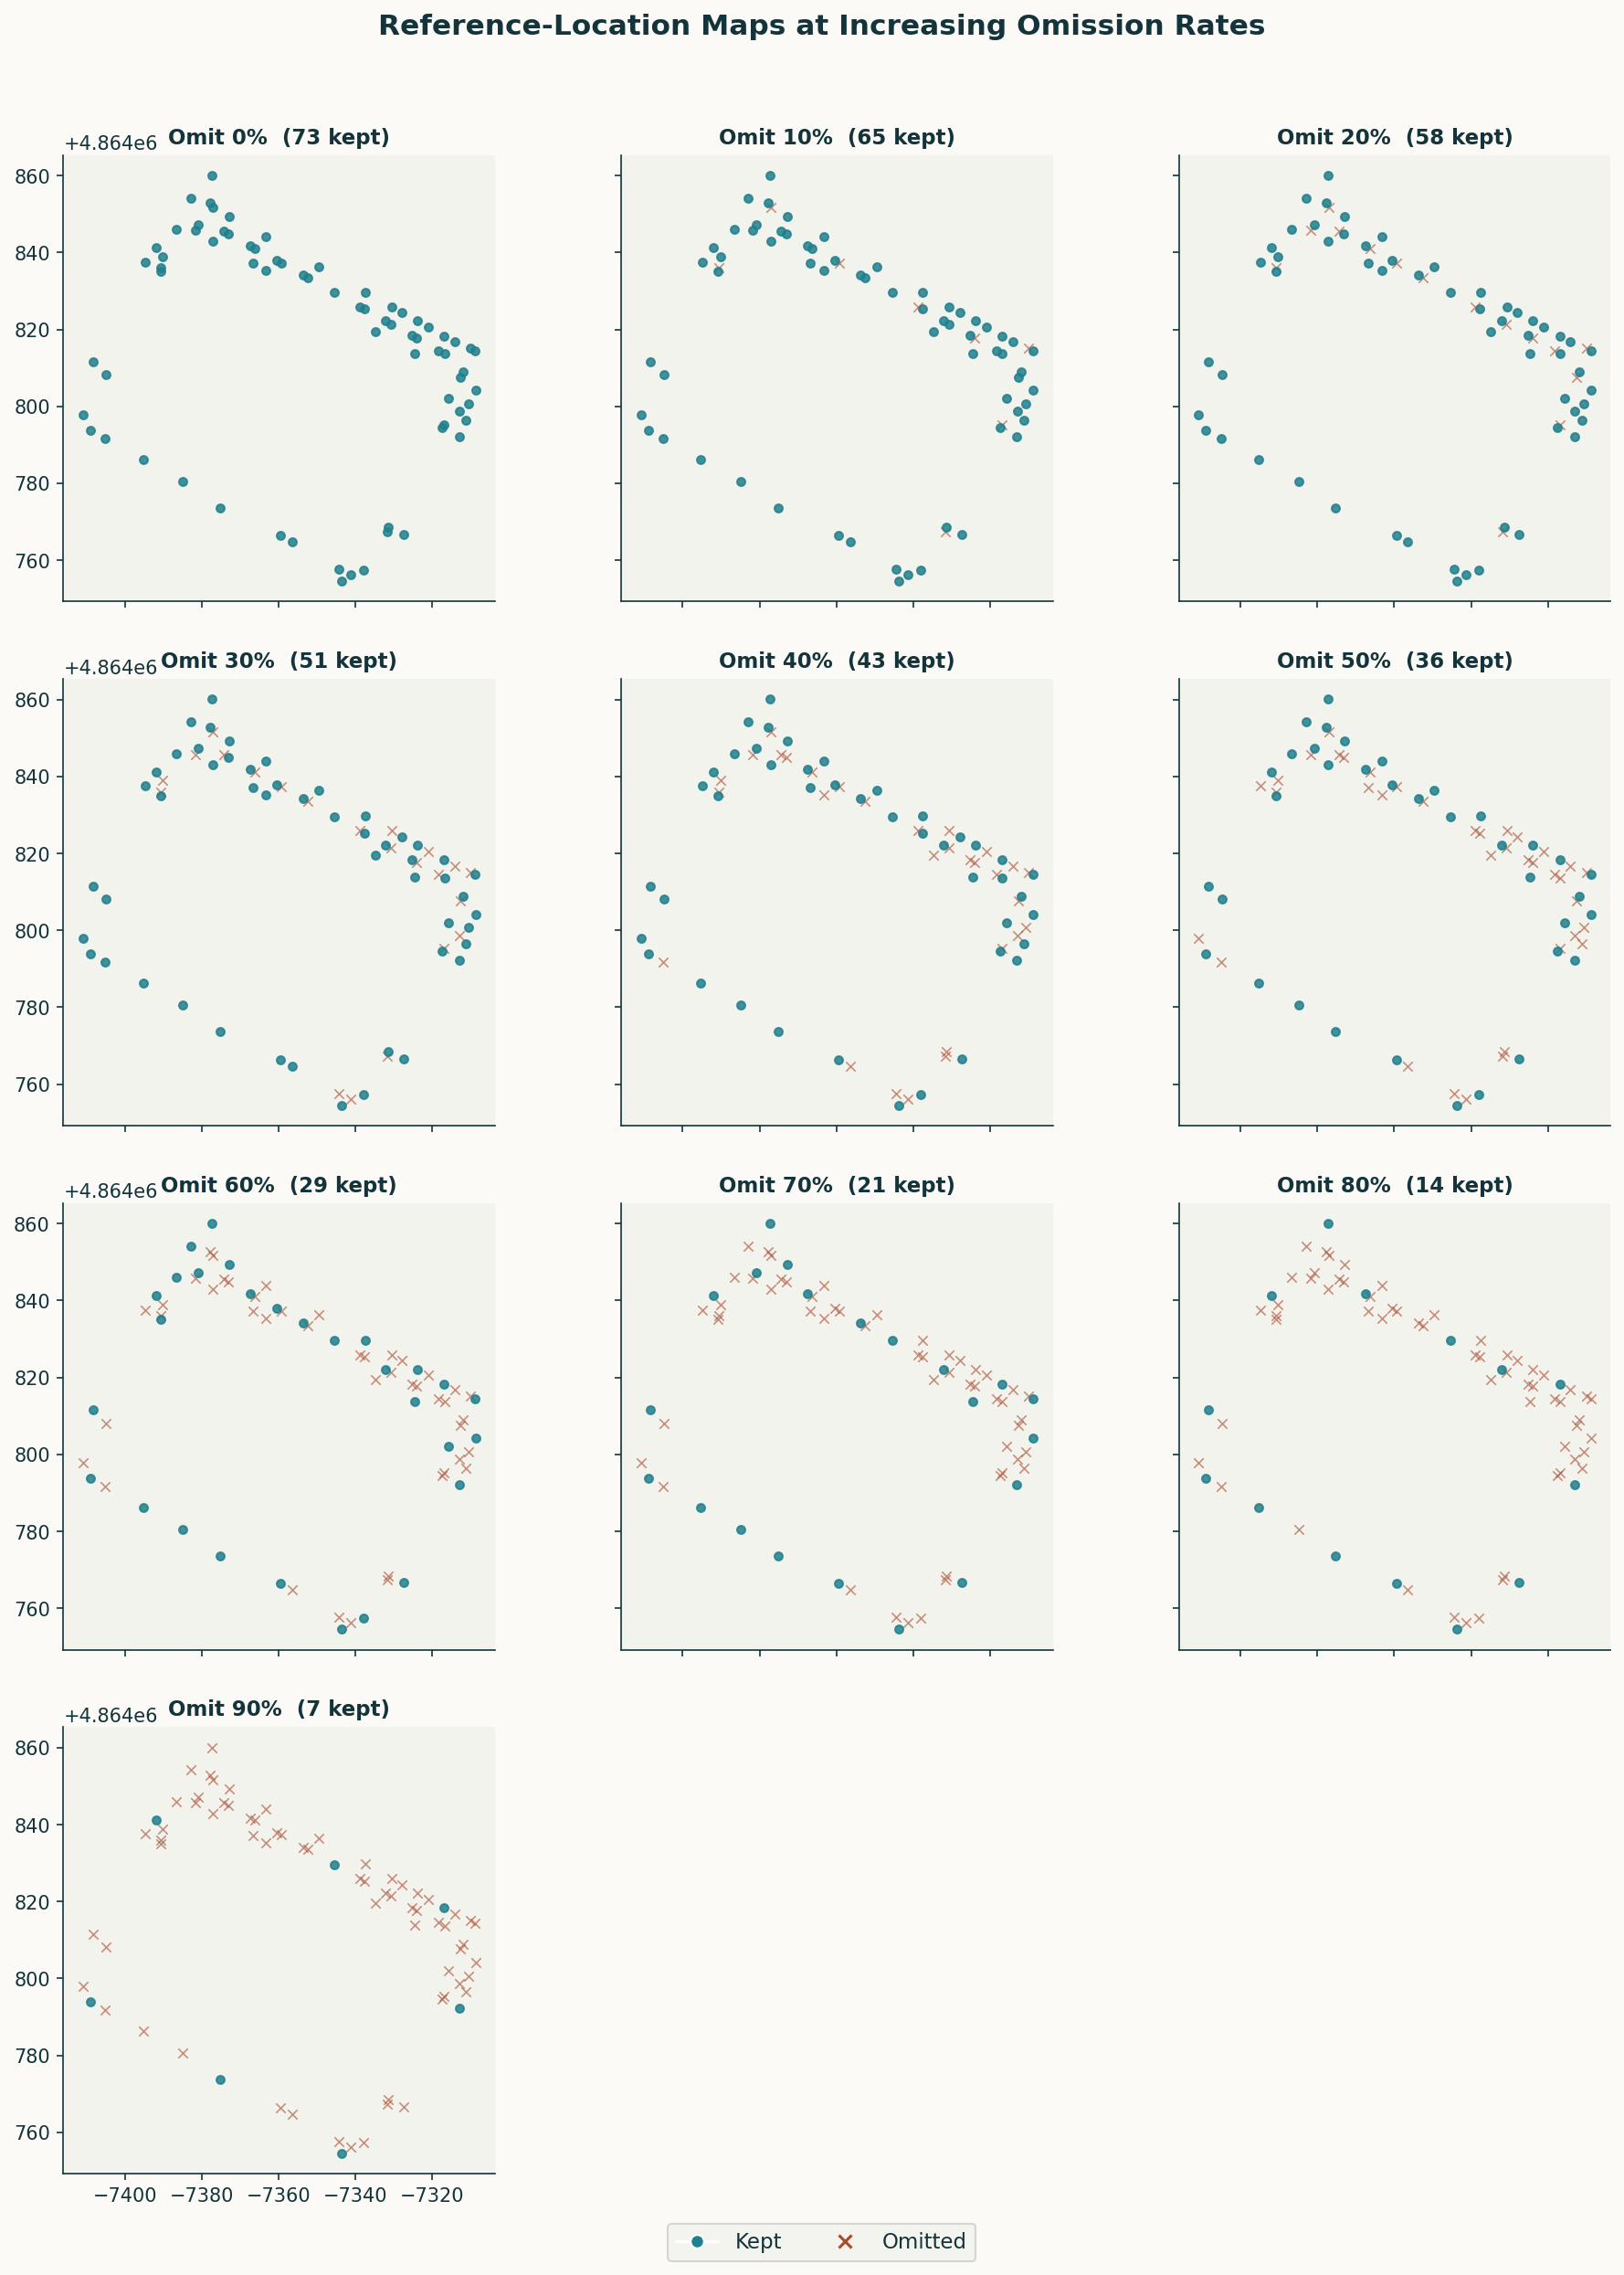

✓ Floor-plan maps saved.


In [ ]:
n_levels = len(OMISSION_PCTS)
n_cols = 3
n_rows = int(np.ceil(n_levels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for idx, pct in enumerate(OMISSION_PCTS):
    ax = axes[idx]
    n_keep = max(1, int(N_LOCS * (1 - pct / 100)))
    kept_idx = fp_order[:n_keep]
    omitted_idx = fp_order[n_keep:]

    kept = unique_locs[kept_idx]
    omitted = unique_locs[omitted_idx] if len(omitted_idx) > 0 else np.empty((0, 2))

    if len(omitted) > 0:
        ax.scatter(omitted[:, 0], omitted[:, 1], c=C["terra"], marker="x",
                   s=25, alpha=0.6, linewidths=0.8, label="Omitted", zorder=2)
    ax.scatter(kept[:, 0], kept[:, 1], c=C["teal"], s=18, alpha=0.85,
               label="Kept", zorder=3)

    ax.set_title(f"Omit {pct}%  ({n_keep} kept)", fontsize=11)
    ax.set_aspect("equal", adjustable="box")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C["teal"],
           markersize=7, label="Kept"),
    Line2D([0], [0], marker="x", color=C["terra"], markeredgewidth=1.5,
           markersize=7, linestyle="None", label="Omitted"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Reference-Location Maps at Increasing Omission Rates",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("floorplan_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Floor-plan maps saved.")

## 4 — Helpers: Preprocessing, Models, HPO

These are the same model definitions and search spaces from the
dual-track pipeline, wrapped into reusable functions.

In [ ]:
# ── Preprocessing ────────────────────────────────────────────────────
def preprocess(df, wap_cols, tx, ty, no_signal, kept_loc_set, seed=42):
    """
    Build X/y arrays, scale, split into train/val/test.

    `kept_loc_set` is a set of (x, y) tuples. Only training/val samples
    whose location is in this set are kept. Test samples are always
    ALL original samples (we test on the full dense grid).
    """
    X_raw = df[wap_cols].copy()
    y_raw = df[[tx, ty]].values.astype(np.float64)
    if no_signal == 100:
        X_raw = X_raw.replace(100, -105)
    X_raw = X_raw.values.astype(np.float64)

    # Fixed train/val/test split on the full data FIRST
    idx_all = np.arange(len(df))
    idx_temp, idx_test = train_test_split(idx_all, test_size=0.20, random_state=seed)
    idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=seed)

    # Filter train & val by kept locations (test stays full)
    def loc_filter(indices):
        mask = np.array([
            (y_raw[i, 0], y_raw[i, 1]) in kept_loc_set
            for i in indices
        ])
        return indices[mask]

    idx_train = loc_filter(idx_train)
    idx_val = loc_filter(idx_val)

    # Fit scalers on filtered training set
    rssi_scaler = MinMaxScaler().fit(X_raw[idx_train])
    coord_scaler = MinMaxScaler().fit(y_raw[idx_train])

    X_tr = rssi_scaler.transform(X_raw[idx_train])
    X_va = rssi_scaler.transform(X_raw[idx_val])
    X_te = rssi_scaler.transform(X_raw[idx_test])
    y_tr = coord_scaler.transform(y_raw[idx_train])
    y_va = coord_scaler.transform(y_raw[idx_val])
    y_te = coord_scaler.transform(y_raw[idx_test])

    return X_tr, X_va, X_te, y_tr, y_va, y_te, coord_scaler


def build_tracks(X_tr, X_va, X_te, y_tr, seed=42):
    """Track A = dead-AP removal; Track B = tree-based feature selection."""
    coverage = (X_tr > 0).mean(axis=0)
    alive = coverage >= 0.05
    X_tr_f, X_va_f, X_te_f = X_tr[:, alive], X_va[:, alive], X_te[:, alive]

    sel = ExtraTreesRegressor(n_estimators=200, random_state=seed, n_jobs=1)
    sel.fit(X_tr_f, y_tr)
    sfm = SelectFromModel(sel, threshold="median", prefit=True)
    X_tr_s = sfm.transform(X_tr_f)
    X_va_s = sfm.transform(X_va_f)
    X_te_s = sfm.transform(X_te_f)

    return {
        "Full": {"tr": X_tr_f, "va": X_va_f, "te": X_te_f, "nf": X_tr_f.shape[1]},
        "Selected": {"tr": X_tr_s, "va": X_va_s, "te": X_te_s, "nf": X_tr_s.shape[1]},
    }


# ── Metric ───────────────────────────────────────────────────────────
def mee_meters(y_true_s, y_pred_s, scaler):
    yt = scaler.inverse_transform(y_true_s)
    yp = scaler.inverse_transform(y_pred_s)
    return np.sqrt(((yt - yp) ** 2).sum(axis=1))


# ── DNN ──────────────────────────────────────────────────────────────
class LocDNN(nn.Module):
    def __init__(self, d_in, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(drop),
            nn.Linear(64, 2),
        )
    def forward(self, x):
        return self.net(x)


def train_dnn(X_tr, y_tr, X_va, y_va, lr, drop, epochs=120, bs=64):
    m = LocDNN(X_tr.shape[1], drop).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=lr)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss()
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr, dtype=torch.float32))
    ld = DataLoader(ds, batch_size=bs, shuffle=True, num_workers=0, pin_memory=False)
    Xv = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
    best, best_st, pat = 1e9, None, 0
    for ep in range(epochs):
        m.train()
        for xb, yb in ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(m(xb), yb); loss.backward(); opt.step()
        sch.step()
        if (ep + 1) % 5 == 0:
            m.eval()
            with torch.no_grad():
                p = m(Xv).cpu().numpy()
            err = np.sqrt(((y_va - p) ** 2).sum(axis=1)).mean()
            if err < best:
                best = err; best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}; pat = 0
            else:
                pat += 5
            if pat >= 30:
                break
    if best_st:
        m.load_state_dict(best_st)
    m.to(DEVICE)
    return m, best


# ── Optuna objectives ────────────────────────────────────────────────
def obj_knn(trial, Xtr, ytr, Xva, yva, cs):
    k = trial.suggest_int("n_neighbors", 1, 15)
    w = trial.suggest_categorical("weights", ["uniform", "distance"])
    mdl = KNeighborsRegressor(n_neighbors=k, weights=w, n_jobs=1)
    mdl.fit(Xtr, ytr)
    return mee_meters(yva, mdl.predict(Xva), cs).mean()

def obj_svr(trial, Xtr, ytr, Xva, yva, cs):
    cc = trial.suggest_categorical("C", [0.1, 1, 10, 100])
    g = trial.suggest_categorical("gamma", ["scale", 0.01, 0.1])
    mdl = MultiOutputRegressor(SVR(C=cc, gamma=g, kernel="rbf"), n_jobs=1)
    mdl.fit(Xtr, ytr)
    return mee_meters(yva, mdl.predict(Xva), cs).mean()

def obj_xgb(trial, Xtr, ytr, Xva, yva, cs):
    p = dict(n_estimators=trial.suggest_int("n_estimators", 100, 300, step=50),
             max_depth=trial.suggest_categorical("max_depth", [3, 5, 7]),
             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
             tree_method="hist", random_state=SEED, verbosity=0)
    mdl = MultiOutputRegressor(xgb.XGBRegressor(**p), n_jobs=1)
    mdl.fit(Xtr, ytr)
    return mee_meters(yva, mdl.predict(Xva), cs).mean()

def obj_dnn(trial, Xtr, ytr, Xva, yva, cs):
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dr = trial.suggest_float("dropout", 0.1, 0.3)
    _, err = train_dnn(Xtr, ytr, Xva, yva, lr, dr, epochs=120)
    return err


# ── Retrain & predict ────────────────────────────────────────────────
def retrain_predict(name, bp, Xtr, ytr, Xva, yva, Xte):
    if name == "kNN":
        m = KNeighborsRegressor(n_neighbors=bp["n_neighbors"], weights=bp["weights"], n_jobs=1)
        m.fit(Xtr, ytr); return m.predict(Xte)
    elif name == "SVR":
        m = MultiOutputRegressor(SVR(C=bp["C"], gamma=bp["gamma"], kernel="rbf"), n_jobs=1)
        m.fit(Xtr, ytr); return m.predict(Xte)
    elif name == "XGBoost":
        p = dict(n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
                 learning_rate=bp["learning_rate"], tree_method="hist",
                 random_state=SEED, verbosity=0)
        m = MultiOutputRegressor(xgb.XGBRegressor(**p), n_jobs=1)
        m.fit(Xtr, ytr); return m.predict(Xte)
    elif name == "DNN":
        m, _ = train_dnn(Xtr, ytr, Xva, yva, bp["lr"], bp["dropout"], epochs=150)
        m.eval()
        with torch.no_grad():
            return m(torch.tensor(Xte, dtype=torch.float32).to(DEVICE)).cpu().numpy()

## 5 — Main Experiment Loop

For each omission percentage → preprocess → build tracks →
HPO for every model × track → evaluate on the full test set.

In [ ]:
MODEL_NAMES = ["kNN", "SVR", "XGBoost", "DNN"]
OBJ_FNS = {"kNN": obj_knn, "SVR": obj_svr, "XGBoost": obj_xgb, "DNN": obj_dnn}
TRACK_NAMES = ["Full", "Selected"]

# Results: {(omit_pct, model, track) → {"mee":, "dists":, "params":, "n_feat":, "n_train":}}
ALL_RESULTS = {}

for pct in OMISSION_PCTS:
    t0 = time.time()
    n_keep = max(1, int(N_LOCS * (1 - pct / 100)))
    kept_idx = fp_order[:n_keep]
    kept_locs = unique_locs[kept_idx]
    kept_set = set(map(tuple, kept_locs.tolist()))

    print(f"\n{'═' * 60}")
    print(f"  OMISSION = {pct}%  │  Keeping {n_keep}/{N_LOCS} locations")
    print(f"{'═' * 60}")

    # Preprocess
    X_tr, X_va, X_te, y_tr, y_va, y_te, cscaler = preprocess(
        df, wap_cols, TX, TY, NO_SIGNAL, kept_set, seed=SEED)
    print(f"  Train: {X_tr.shape[0]} | Val: {X_va.shape[0]} | Test: {X_te.shape[0]}")

    if X_tr.shape[0] < 5 or X_va.shape[0] < 5:
        print("  ⚠ Not enough samples, skipping this level.")
        continue

    tracks = build_tracks(X_tr, X_va, X_te, y_tr, seed=SEED)

    for mname in MODEL_NAMES:
        for tname in TRACK_NAMES:
            td = tracks[tname]
            key = (pct, mname, tname)
            print(f"  ── {mname} / {tname} ({td['nf']} feat) ", end="", flush=True)

            sampler = optuna.samplers.TPESampler(seed=SEED)
            study = optuna.create_study(direction="minimize", sampler=sampler)
            study.optimize(
                lambda trial, _mname=mname, _td=td: OBJ_FNS[_mname](
                    trial, _td["tr"], y_tr, _td["va"], y_va, cscaler),
                n_trials=N_TRIALS, show_progress_bar=False)

            bp = study.best_params
            pred = retrain_predict(mname, bp, td["tr"], y_tr, td["va"], y_va, td["te"])
            dists = mee_meters(y_te, pred, cscaler)
            mee = dists.mean()

            ALL_RESULTS[key] = {
                "mee": mee, "dists": dists, "params": bp,
                "n_feat": td["nf"], "n_train": td["tr"].shape[0],
            }
            print(f"→ MEE = {mee:.3f} m  (best: {bp})")

    print(f"  ⏱ Level completed in {time.time()-t0:.0f}s")

print("\n✓ All omission levels complete.")


════════════════════════════════════════════════════════════
  OMISSION = 0%  │  Keeping 73/73 locations
════════════════════════════════════════════════════════════
  Train: 945 | Val: 316 | Test: 316
  ── kNN / Full (62 feat) → MEE = 1.889 m  (best: {'n_neighbors': 1, 'weights': 'uniform'})
  ── kNN / Selected (31 feat) → MEE = 2.103 m  (best: {'n_neighbors': 1, 'weights': 'uniform'})
  ── SVR / Full (62 feat) → MEE = 8.524 m  (best: {'C': 1, 'gamma': 0.1})
  ── SVR / Selected (31 feat) → MEE = 7.981 m  (best: {'C': 10, 'gamma': 0.1})
  ── XGBoost / Full (62 feat) → MEE = 3.054 m  (best: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.028580510658069373})
  ── XGBoost / Selected (31 feat) → MEE = 3.088 m  (best: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.0923915031962725})
  ── DNN / Full (62 feat) → MEE = 4.306 m  (best: {'lr': 0.0006798962421591129, 'dropout': 0.14246782213565523})
  ── DNN / Selected (31 feat) → MEE = 4.601 m  (best: {'lr': 0.00067989624215

## 6 — Results Table

In [ ]:
rows = []
for (pct, mname, tname), r in sorted(ALL_RESULTS.items()):
    rows.append({
        "Omit %": pct, "Model": mname, "Track": tname,
        "Features": r["n_feat"], "Train N": r["n_train"],
        "MEE (m)": round(r["mee"], 3),
        "P50 (m)": round(np.median(r["dists"]), 3),
        "P90 (m)": round(np.percentile(r["dists"], 90), 3),
    })
results_df = pd.DataFrame(rows)
print(results_df.to_markdown(index=False))

|   Omit % | Model   | Track    |   Features |   Train N |   MEE (m) |   P50 (m) |   P90 (m) |
|---------:|:--------|:---------|-----------:|----------:|----------:|----------:|----------:|
|        0 | DNN     | Full     |         62 |       945 |     4.306 |     3.492 |     8.116 |
|        0 | DNN     | Selected |         31 |       945 |     4.601 |     3.41  |     8.985 |
|        0 | SVR     | Full     |         62 |       945 |     8.524 |     7.721 |    14.069 |
|        0 | SVR     | Selected |         31 |       945 |     7.981 |     7.027 |    14.105 |
|        0 | XGBoost | Full     |         62 |       945 |     3.054 |     2.02  |     6.766 |
|        0 | XGBoost | Selected |         31 |       945 |     3.088 |     2.048 |     6.212 |
|        0 | kNN     | Full     |         62 |       945 |     1.889 |     0     |     6.625 |
|        0 | kNN     | Selected |         31 |       945 |     2.103 |     0     |     6.925 |
|       10 | DNN     | Full     |         62 |    

## 6b — Compact MEE Table: All Models × Sparsity Levels (Full Track)

MEE (m) for each regression model at every omission level on the Full feature track.
**Bold** values indicate the best (lowest) MEE at each sparsity level.

In [ ]:
# ── Compact MEE Table (Table III style) ─────────────────────────────
# Rows = models, Columns = omission percentages (Full track only)

print("\n" + "═" * 70)
print("  MEE (m) FOR ALL MODELS VS. SPARSITY LEVEL (Full Track)")
print("═" * 70 + "\n")

# Collect MEE values: model → {pct → mee}
mee_table = {}
for mname in MODEL_NAMES:
    mee_table[mname] = {}
    for pct in OMISSION_PCTS:
        key = (pct, mname, "Full")
        if key in ALL_RESULTS:
            mee_table[mname][pct] = ALL_RESULTS[key]["mee"]

# Find best (minimum) MEE per omission level
best_per_pct = {}
for pct in OMISSION_PCTS:
    vals = [(mname, mee_table[mname][pct])
            for mname in MODEL_NAMES if pct in mee_table[mname]]
    if vals:
        best_per_pct[pct] = min(vals, key=lambda x: x[1])[1]

# Build header
pct_headers = [f"{p}%" for p in OMISSION_PCTS]
header = f"{'Model':<12}" + "".join(f"{h:>8}" for h in pct_headers)
sep = "─" * len(header)
print(header)
print(sep)

# Build rows with bold markers for best values
for mname in MODEL_NAMES:
    row = f"{mname:<12}"
    for pct in OMISSION_PCTS:
        if pct in mee_table[mname]:
            val = mee_table[mname][pct]
            val_str = f"{val:.2f}"
            # Mark best with asterisk
            if pct in best_per_pct and abs(val - best_per_pct[pct]) < 1e-6:
                val_str = f"*{val_str}*"
            row += f"{val_str:>8}"
        else:
            row += f"{'—':>8}"
    print(row)

print(sep)
print("* = best model at that sparsity level")

# Also create a pandas DataFrame for clean display
table_rows = []
for mname in MODEL_NAMES:
    row_dict = {"Model": mname}
    for pct in OMISSION_PCTS:
        if pct in mee_table[mname]:
            row_dict[f"{pct}%"] = round(mee_table[mname][pct], 2)
        else:
            row_dict[f"{pct}%"] = None
    table_rows.append(row_dict)

compact_df = pd.DataFrame(table_rows)
print("\n")
print(compact_df.to_markdown(index=False))



══════════════════════════════════════════════════════════════════════
  MEE (m) FOR ALL MODELS VS. SPARSITY LEVEL (Full Track)
══════════════════════════════════════════════════════════════════════

Model             0%     10%     20%     30%     40%     50%     60%     70%     80%     90%
────────────────────────────────────────────────────────────────────────────────────────────
kNN           *1.89*  *2.36*  *2.47*  *2.51*  *3.36*  *4.08*  *4.94*  *6.08*  *8.37* *13.65*
SVR             8.52    8.98    9.20    9.51   10.05    9.81    9.81   10.54   12.62   19.06
XGBoost         3.05    3.92    4.32    3.97    4.67    5.65    5.62    7.65   11.69   20.79
DNN             4.31    4.91    5.06    5.84    5.88    7.21    7.80    9.73   12.38   22.19
────────────────────────────────────────────────────────────────────────────────────────────
* = best model at that sparsity level


| Model   |   0% |   10% |   20% |   30% |   40% |   50% |   60% |   70% |   80% |   90% |
|:--------|-----:

## 7 — Plot: Degradation Curves (MEE vs. Omission %)

One subplot per model. Solid = Full features, dashed = Selected.

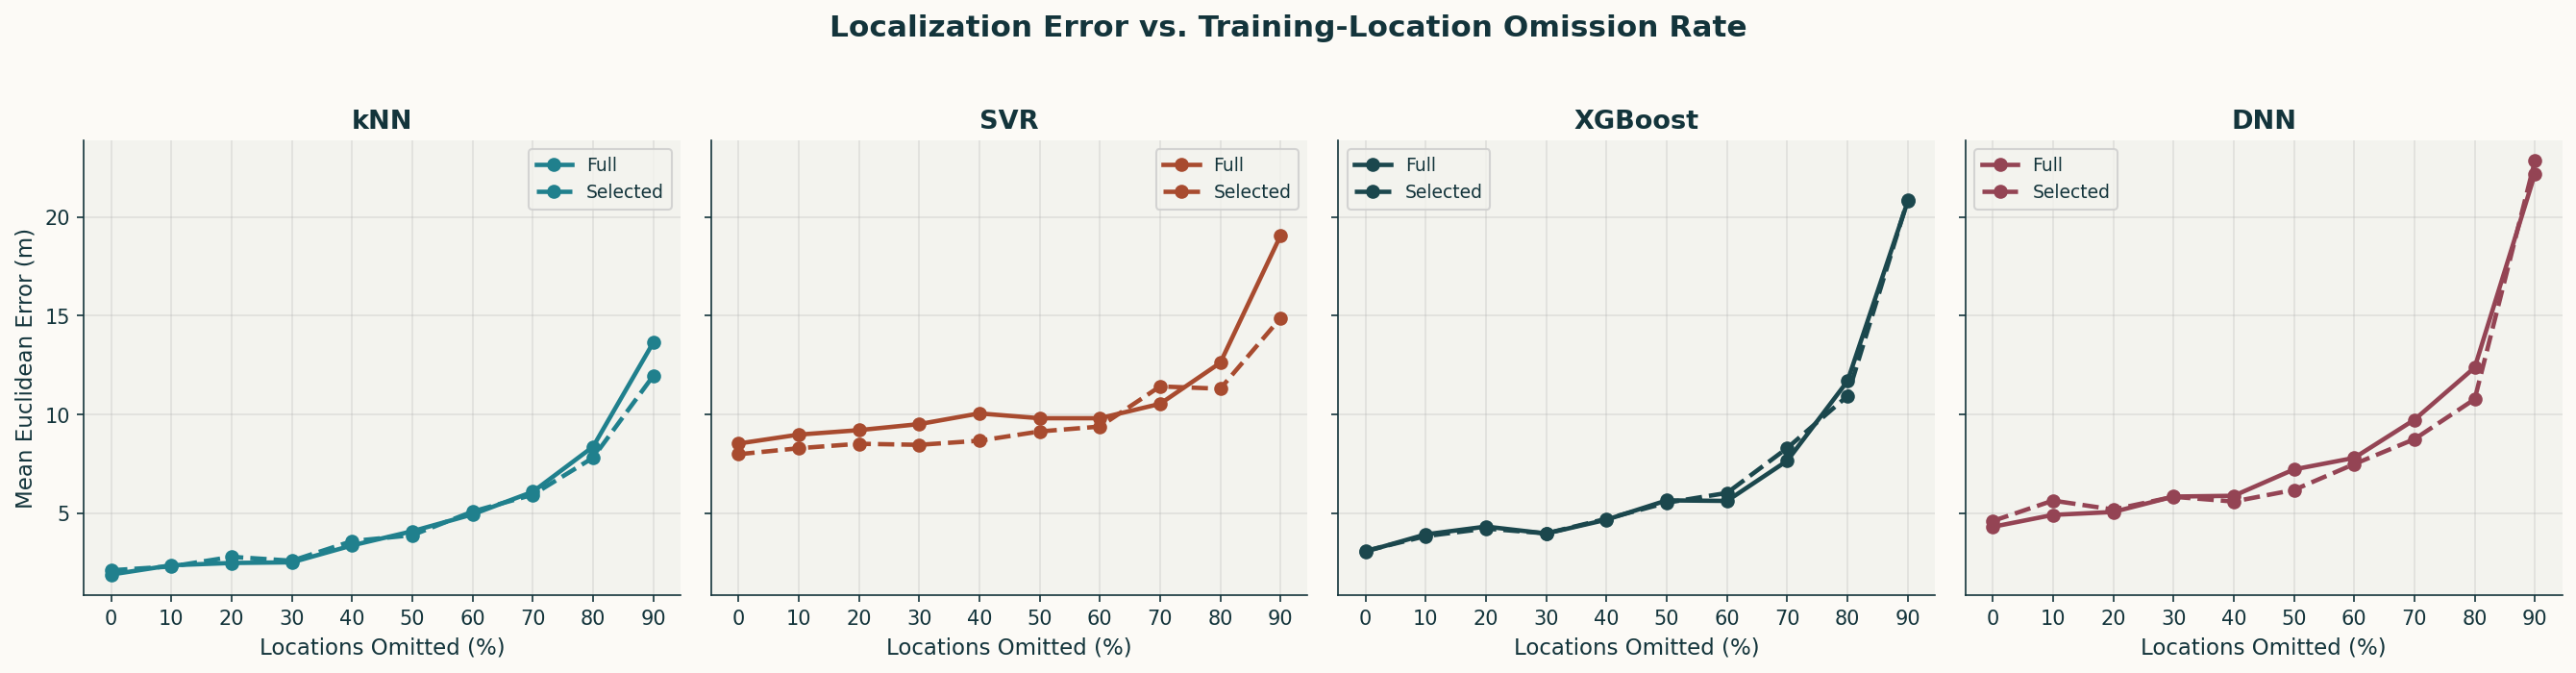

✓ Degradation curves saved.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, mname in enumerate(MODEL_NAMES):
    ax = axes[i]
    for j, tname in enumerate(TRACK_NAMES):
        pcts_plot, mees_plot = [], []
        for pct in OMISSION_PCTS:
            key = (pct, mname, tname)
            if key in ALL_RESULTS:
                pcts_plot.append(pct)
                mees_plot.append(ALL_RESULTS[key]["mee"])
        ls = "-" if tname == "Full" else "--"
        color = CHART_SEQ[i]
        ax.plot(pcts_plot, mees_plot, ls, color=color, linewidth=2.2,
                marker="o", markersize=6, label=tname)
    ax.set_title(mname, fontsize=13)
    ax.set_xlabel("Locations Omitted (%)")
    if i == 0:
        ax.set_ylabel("Mean Euclidean Error (m)")
    ax.legend(frameon=True, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks(OMISSION_PCTS)
    ax.grid(True, alpha=0.3)

fig.suptitle("Localization Error vs. Training-Location Omission Rate",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("degradation_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Degradation curves saved.")

## 8 — Plot: CDF Curves for All Models at Increasing Sparsity

One subplot per model showing how the error distribution shifts as data
becomes sparser. Selected omission levels: 0 %, 30 %, 50 %, 70 %, 90 %.

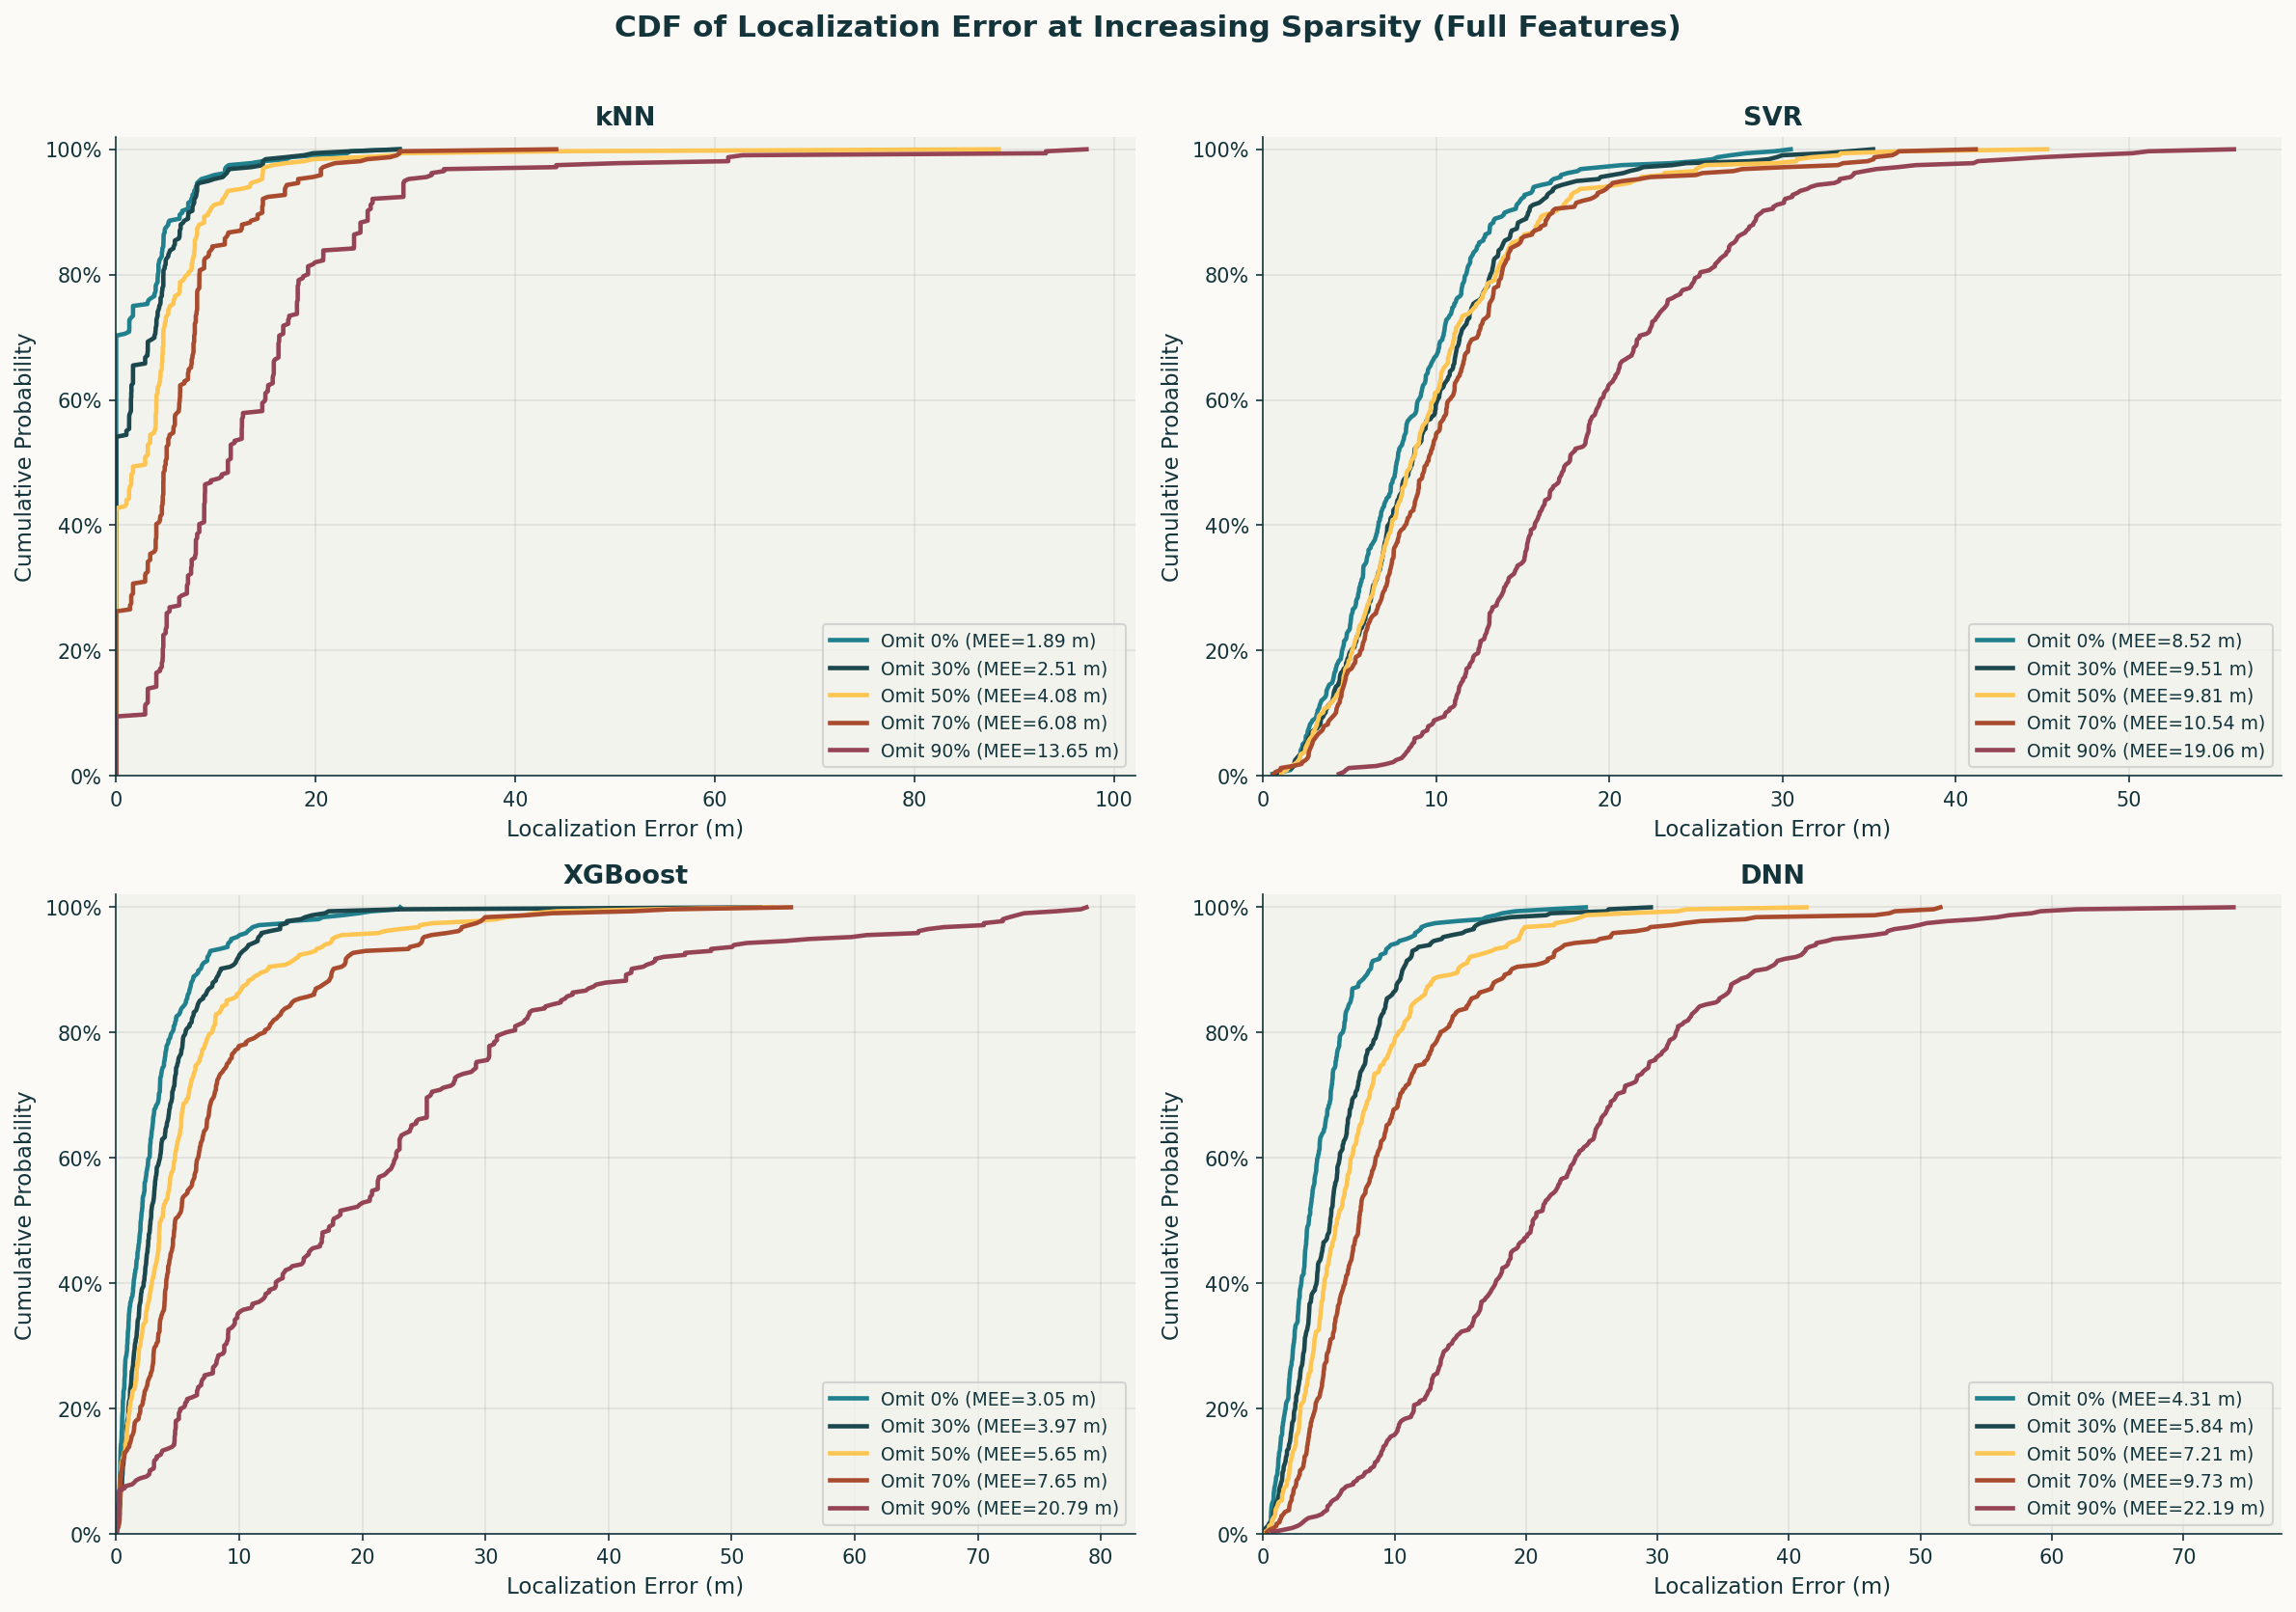

✓ CDF plots saved (all 4 models).


In [ ]:
cdf_pcts_show = [0, 30, 50, 70, 90]
cmap_vals = [C["teal"], C["dark_teal"], C["gold"], C["terra"], C["mauve"]]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes_flat = axes.flatten()

for mi, mname in enumerate(MODEL_NAMES):
    ax = axes_flat[mi]
    valid_pcts = [p for p in cdf_pcts_show if (p, mname, "Full") in ALL_RESULTS]

    for idx, pct in enumerate(valid_pcts):
        d = np.sort(ALL_RESULTS[(pct, mname, "Full")]["dists"])
        cdf = np.arange(1, len(d) + 1) / len(d)
        mee_val = ALL_RESULTS[(pct, mname, "Full")]["mee"]
        ax.plot(d, cdf, color=cmap_vals[idx % len(cmap_vals)], linewidth=2.2,
                label=f"Omit {pct}% (MEE={mee_val:.2f} m)")

    ax.set_xlabel("Localization Error (m)")
    ax.set_ylabel("Cumulative Probability")
    ax.set_title(f"{mname}", fontsize=13)
    ax.legend(frameon=True, fontsize=9, loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.grid(True, alpha=0.3)

fig.suptitle("CDF of Localization Error at Increasing Sparsity (Full Features)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("cdf_sparsification.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ CDF plots saved (all 4 models).")

## 9 — Heatmap: MEE across Models × Omission Levels (Full Track)

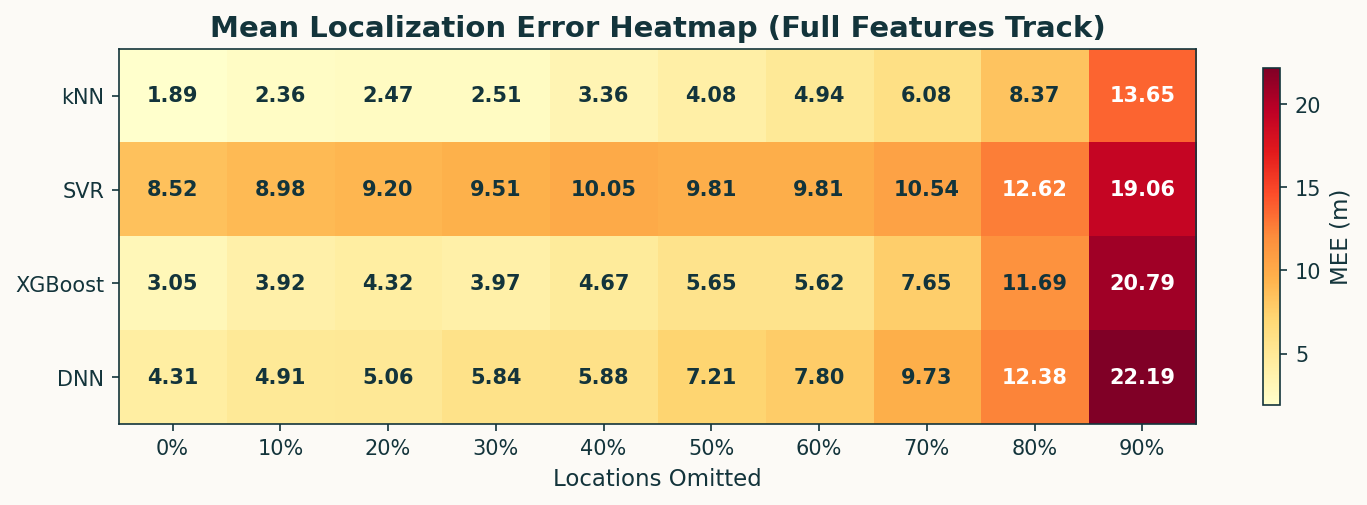

✓ Heatmap saved.


In [ ]:
heat_data = []
for mname in MODEL_NAMES:
    row = []
    for pct in OMISSION_PCTS:
        key = (pct, mname, "Full")
        row.append(ALL_RESULTS[key]["mee"] if key in ALL_RESULTS else np.nan)
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=MODEL_NAMES,
                       columns=[f"{p}%" for p in OMISSION_PCTS])

fig, ax = plt.subplots(figsize=(10, 3.5))
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=heat_df.min().min(), vmax=heat_df.max().max())
im = ax.imshow(heat_df.values, cmap="YlOrRd", aspect="auto", norm=norm)
ax.set_xticks(range(len(OMISSION_PCTS)))
ax.set_xticklabels([f"{p}%" for p in OMISSION_PCTS])
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES)
ax.set_xlabel("Locations Omitted")
ax.set_title("Mean Localization Error Heatmap (Full Features Track)", fontweight="bold")

# Annotate cells
for i in range(len(MODEL_NAMES)):
    for j in range(len(OMISSION_PCTS)):
        val = heat_df.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val > (heat_df.max().max() + heat_df.min().min()) / 2 else C["offblack"]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="MEE (m)", shrink=0.9)
plt.tight_layout()
plt.savefig("heatmap_sparsification.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Heatmap saved.")

## 10 — Grouped Bar Chart at Every Omission Level (Full vs Selected)

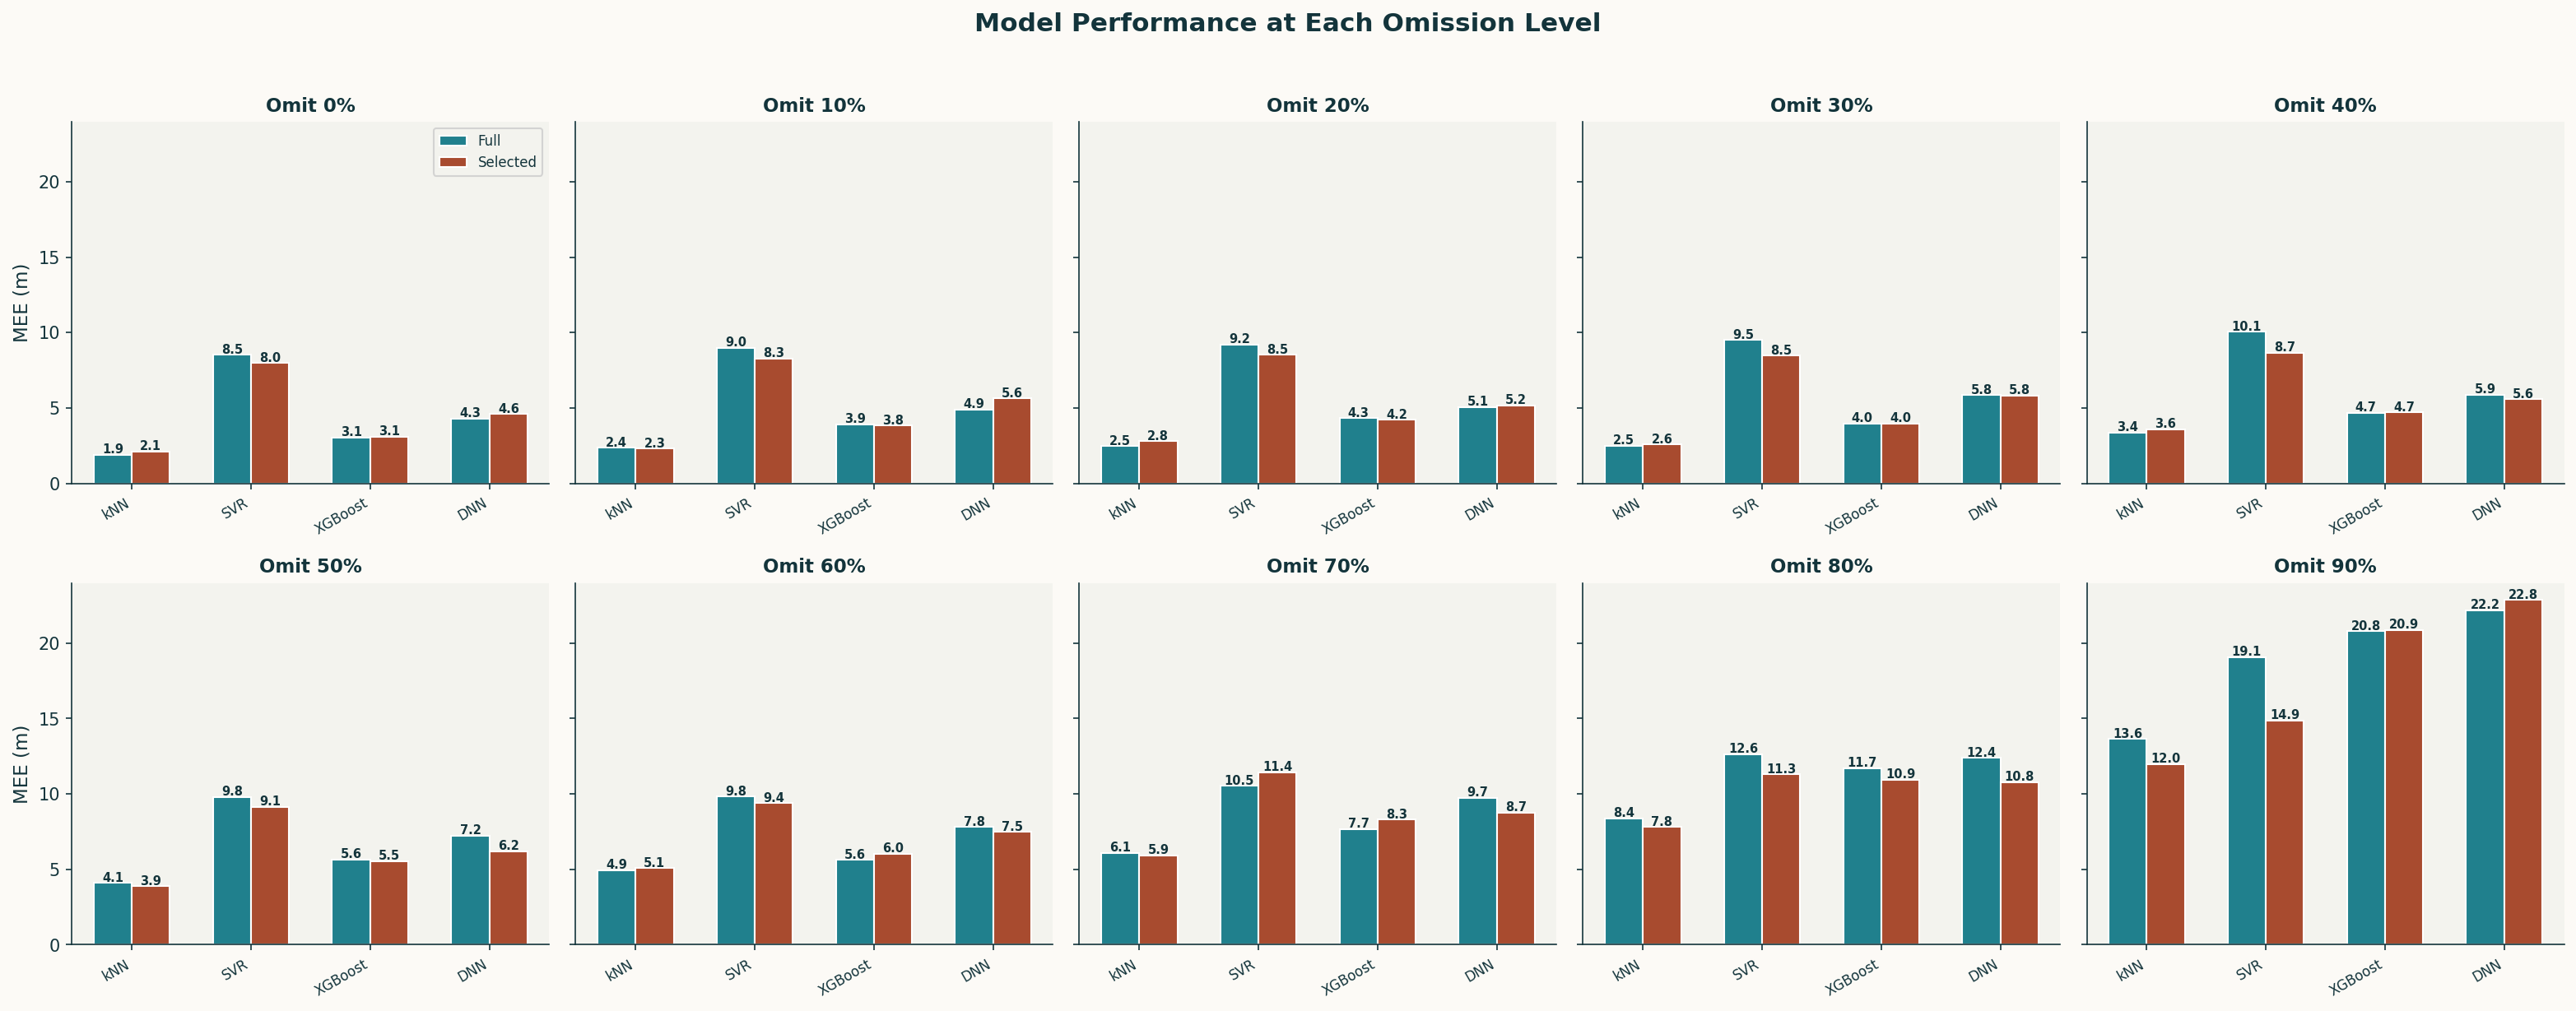

✓ Grouped bar charts saved.


In [ ]:
n_bar_cols = 5
n_bar_rows = int(np.ceil(len(OMISSION_PCTS) / n_bar_cols))
fig, axes = plt.subplots(n_bar_rows, n_bar_cols, figsize=(4.2 * n_bar_cols, 4 * n_bar_rows),
                         sharey=True)
axes_flat = axes.flatten()

for idx, pct in enumerate(OMISSION_PCTS):
    ax = axes_flat[idx]
    mees_f = [ALL_RESULTS.get((pct, m, "Full"), {}).get("mee", np.nan) for m in MODEL_NAMES]
    mees_s = [ALL_RESULTS.get((pct, m, "Selected"), {}).get("mee", np.nan) for m in MODEL_NAMES]

    x = np.arange(len(MODEL_NAMES))
    w = 0.32
    ax.bar(x - w/2, mees_f, w, color=C["teal"], edgecolor="white", label="Full")
    ax.bar(x + w/2, mees_s, w, color=C["terra"], edgecolor="white", label="Selected")

    # Value labels
    for xi, (vf, vs) in enumerate(zip(mees_f, mees_s)):
        if not np.isnan(vf):
            ax.text(xi - w/2, vf + 0.1, f"{vf:.1f}", ha="center", fontsize=7, fontweight="bold")
        if not np.isnan(vs):
            ax.text(xi + w/2, vs + 0.1, f"{vs:.1f}", ha="center", fontsize=7, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, fontsize=8, rotation=30, ha="right")
    ax.set_title(f"Omit {pct}%", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if idx % n_bar_cols == 0:
        ax.set_ylabel("MEE (m)")
    if idx == 0:
        ax.legend(fontsize=8, frameon=True)

for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Model Performance at Each Omission Level",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("grouped_bars_all_levels.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grouped bar charts saved.")

## 11 — Summary: Relative Degradation Table

How much does each model's error increase (%) relative to its baseline (0% omission)?

In [ ]:
print("\n═══ Relative Degradation (% increase in MEE vs. 0% omission) ═══\n")
degrad_rows = []
for mname in MODEL_NAMES:
    for tname in TRACK_NAMES:
        base_key = (0, mname, tname)
        if base_key not in ALL_RESULTS:
            continue
        base_mee = ALL_RESULTS[base_key]["mee"]
        for pct in OMISSION_PCTS:
            key = (pct, mname, tname)
            if key not in ALL_RESULTS:
                continue
            mee = ALL_RESULTS[key]["mee"]
            rel = (mee - base_mee) / base_mee * 100
            degrad_rows.append({
                "Model": mname, "Track": tname, "Omit %": pct,
                "MEE (m)": round(mee, 3),
                "Δ vs 0%": f"+{rel:.1f}%" if rel > 0 else f"{rel:.1f}%",
            })

degrad_df = pd.DataFrame(degrad_rows)
print(degrad_df.to_markdown(index=False))

# Save all results to JSON
export = {}
for (pct, mname, tname), r in ALL_RESULTS.items():
    export[f"{pct}|{mname}|{tname}"] = {
        "mee": round(r["mee"], 4), "n_feat": r["n_feat"],
        "n_train": r["n_train"], "params": r["params"],
    }
with open("sparsification_results.json", "w") as f:
    json.dump(export, f, indent=2, default=str)
print("\n✓ Results exported to sparsification_results.json")


═══ Relative Degradation (% increase in MEE vs. 0% omission) ═══

| Model   | Track    |   Omit % |   MEE (m) | Δ vs 0%   |
|:--------|:---------|---------:|----------:|:----------|
| kNN     | Full     |        0 |     1.889 | 0.0%      |
| kNN     | Full     |       10 |     2.359 | +24.9%    |
| kNN     | Full     |       20 |     2.474 | +31.0%    |
| kNN     | Full     |       30 |     2.507 | +32.7%    |
| kNN     | Full     |       40 |     3.364 | +78.1%    |
| kNN     | Full     |       50 |     4.083 | +116.1%   |
| kNN     | Full     |       60 |     4.937 | +161.3%   |
| kNN     | Full     |       70 |     6.082 | +222.0%   |
| kNN     | Full     |       80 |     8.367 | +342.9%   |
| kNN     | Full     |       90 |    13.645 | +622.3%   |
| kNN     | Selected |        0 |     2.103 | 0.0%      |
| kNN     | Selected |       10 |     2.297 | +9.2%     |
| kNN     | Selected |       20 |     2.785 | +32.4%    |
| kNN     | Selected |       30 |     2.587 | +23.0%    |
| kNN